# Прогнозирование оттока клиентов "ТелеДом"

<p>
<details>
    <summary><b>Описание проекта</b></summary><div style="margin: 10px 0 10px 20px;">

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах.
</div></details>
</p>

<p>
<details>
    <summary><b>Задача</b></summary><div style="margin: 10px 0 10px 20px;">

Обучить на этих данных модель для прогноза оттока клиентов.
Цель - ROC-AUC > 0.85
</div></details>
</p>

<p>
<details><summary><b>Описание услуг</b></summary><div style="margin: 10px 0 10px 20px;">

Оператор предоставляет два основных типа услуг:
- Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
- Интернет. Подключение может быть двух типов: через телефонную линию (`DSL`, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (`Fiber optic`).

Также доступны такие услуги:
- Интернет-безопасность: антивирус (`DeviceProtection`) и блокировка небезопасных сайтов (`OnlineSecurity`);
- Выделенная линия технической поддержки (`TechSupport`);
- Облачное хранилище файлов для резервного копирования данных (`OnlineBackup`);
- Стриминговое телевидение (`StreamingTV`) и каталог фильмов (`StreamingMovies`).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.
</div></details>
</p>

<p>
<details><summary><b>Общие выводы</b></summary><div style="margin: 10px 0 10px 20px;">

- Размер выборки ~7 000 клиентов

- Есть выбросы в `TotalCharges` для новых пользователей нет значений. Пропуски заменены на 0

- Целевая переменная `is_active_contract` имеет сильный дисбаланс

- Большой отток клиентов идет либо в начале, либо от большого значения `MonthlyCharges`

- Составлена сравнительная таблица, отсортированная от лучшей до худшей модели, согласно метрики ROC-AUC

- __Лучшая модель - LightGBMClassifier__ со следующими параметрами:
    - `num_leaves`: 22
    - `max_depth`: 16
    - `learning_rate`: 0.45

- Значение метрики __ROC-AUC__ на лучшей модели на тестовой выборке равно __0.88__, что больше заявленных __0.89__

- Ансамбль показал немного хуже результаты (ROC-AUC ~= 0.88)
</div></details>
</p>

<p>
<details><summary><b>Рекомендации</b></summary><div style="margin: 10px 0 10px 20px;">
Исходя из важности признаков:

1. `tenure_days` (с большим отрывом лидер)

Чем дольше клиент остаётся, тем меньше риск оттока. Первые месяцы — самые критичные для удержания.

2. `MonthlyCharges` и `TotalCharges`

Высокая ежемесячная плата повышает риск оттока (особенно если это новые клиенты). Дорогие тарифы требуют дополнительных преимуществ (скидки, бонусы, гибкость тарифа).

3. `Type_Two year` и `Type_One year` (длительность контракта)

Годовые и двухгодовые контракты резко снижают отток. Стимулировать переход с помесячного тарифа на годовой (например, бонус + бесплатный месяц).

4. `Partner` (есть ли супруг/супруга)

Клиенты с партнёром стабильнее. Одиноким клиентам стоит предложить дополнительные «привязки» (например, скидку на семейный тариф).

5. `OnlineBackup` и `MultipleLines`

Дополнительные услуги снижают отток: чем больше сервисов подключено, тем меньше вероятность ухода. Продвигать покупку сразу нескольких услуг.

6. `PaymentMethod_Mailed check`

Почтовый чек — "устаревший" метод, такие клиенты чаще уходят. Мотивировать переход на автоплатежи или онлайн-оплату.

7. `gender_Male` (относительно слабый фактор)

Разница между мужчинами и женщинами есть, но она гораздо слабее, чем у других признаков.
</div></details>
</p>

In [1]:
!pip install -q phik
!pip install --upgrade -q scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

In [3]:
# Константы
TODAY = pd.Timestamp('2020-02-01') # Информация о договорах актуальна на 1 февраля 2020 года.
RANDOM_STATE = 110825

## Загрузка данных

In [4]:
def load_df(filename, sep=',', decimal='.'):
    pth1 = "./datasets/" + filename
    pth2 = '' + filename

    if os.path.exists(pth1):
        df = pd.read_csv(pth1, sep=sep, decimal=decimal)
    else:
        df = pd.read_csv(pth2, sep=sep, decimal=decimal)

    print('\n\tПервые строки датафрейма')
    display(df.head())

    print('\n\n\tИнформация о датафрейме\n')
    df.info()

    if not df.select_dtypes(exclude='object').empty:
        print('\n\n\tОписательная статистика о количественных признаках')
        display(df.describe().T)

    if not df.select_dtypes(include='object').empty:
        print('\n\n\tОписательная статистика о качественных признаках')
        display(df.describe(include='object').T)

    return df

### `contract_new`

In [5]:
contract = load_df('contract_new.csv')


	Первые строки датафрейма


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5




	Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


	Описательная статистика о количественных признаках


,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75




	Описательная статистика о качественных признаках


,count,unique,top,freq
customerID,7043,7043,4090-KPJIP,1
BeginDate,7043,77,2014-02-01,366
EndDate,7043,67,No,5942
Type,7043,3,Month-to-month,3875
PaperlessBilling,7043,2,Yes,4171
PaymentMethod,7043,4,Electronic check,2365
TotalCharges,7043,6658,,11


### `personal`

In [6]:
personal = load_df('personal_new.csv')


	Первые строки датафрейма


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No




	Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


	Описательная статистика о количественных признаках


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0




	Описательная статистика о качественных признаках


,count,unique,top,freq
customerID,7043,7043,4090-KPJIP,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933


### `internet`

In [7]:
internet = load_df('internet_new.csv')


	Первые строки датафрейма


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No




	Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


	Описательная статистика о качественных признаках


,count,unique,top,freq
customerID,5517,5517,2568-OIADY,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785


### `phone`

In [8]:
phone = load_df('phone_new.csv')


	Первые строки датафрейма


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes




	Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


	Описательная статистика о качественных признаках


,count,unique,top,freq
customerID,6361,6361,4090-KPJIP,1
MultipleLines,6361,2,No,3390


__Выводы__

Пропусков нигде нет, в основном проблемы в типах данных


## Исследовательский анализ и предобработка данных

In [9]:
def replace_with_bool(df):
    for col in df.columns:
        if df[col].dtype == 'object' and set(map(str.lower, df[col].unique().tolist())) == {'yes', 'no'}:
            df[col] = df[col].str.lower()
            df[col] = df[col].map(lambda x: True if x == 'yes' else False)

    return df

### `contract`

In [10]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [11]:
contract.duplicated().sum()

0

In [12]:
contract.head(2)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84


In [13]:
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

In [14]:
contract['EndDate'].value_counts()

No            5942
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
              ... 
2014-09-01       2
2014-12-01       2
2014-06-01       1
2014-10-01       1
2014-11-01       1
Name: EndDate, Length: 67, dtype: int64

In [15]:
contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

In [16]:
# Замена пропусков на "сегодня"
contract['EndDate_filled'] = contract['EndDate'].fillna(TODAY)
# Считаем длительность обслуживания в месяцах
contract['tenure_days'] = (contract['EndDate_filled'] - contract['BeginDate']).dt.days

In [17]:
# Договор еще не закончился
contract['is_active_contract'] = contract['EndDate'].isna()

In [18]:
# Проверка на то, что нет случаев, где дата начала после даты завершения
(contract['BeginDate'] > contract['EndDate']).sum()

0

In [19]:
# Даты больше не нужны
contract = contract.drop(axis=1, columns=['BeginDate', 'EndDate', 'EndDate_filled'])

In [20]:
contract['Type'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Type, dtype: int64

In [21]:
# contract = replace_with_bool(contract)

In [22]:
contract['PaymentMethod'].value_counts()

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


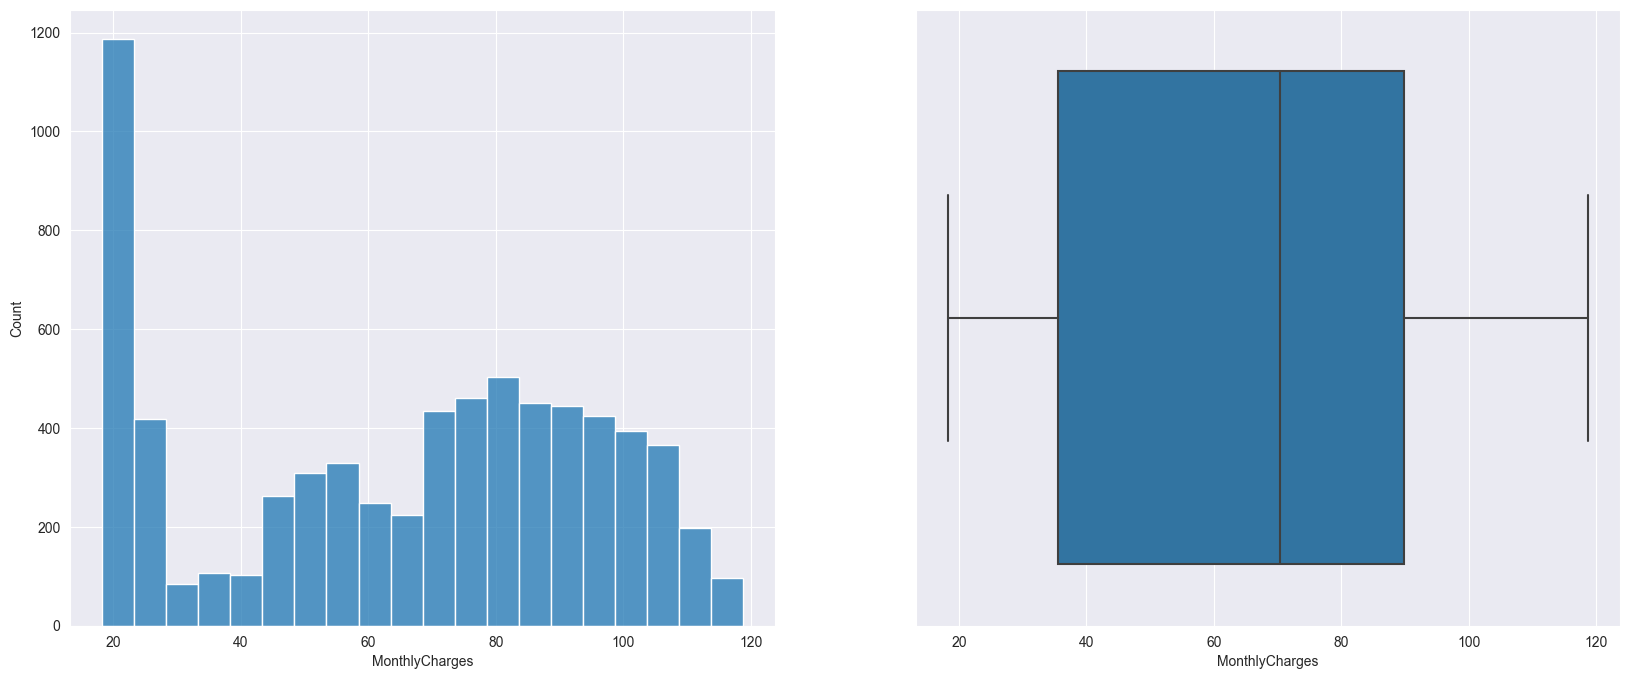

In [23]:
fig = plt.figure(figsize=(20, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
sns.histplot(contract['MonthlyCharges'], kde=False, bins=20, ax=ax1)
sns.boxplot(contract['MonthlyCharges'], ax=ax2)
plt.show()

In [24]:
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')

In [25]:
contract['TotalCharges'].isna().sum()

11

In [26]:
contract[contract['TotalCharges'].isna()]

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_days,is_active_contract
488,4472-LVYGI,Two year,Yes,Bank transfer (automatic),52.55,NaN,0,True
753,3115-CZMZD,Two year,No,Mailed check,20.25,NaN,0,True
936,5709-LVOEQ,Two year,No,Mailed check,80.85,NaN,0,True
1082,4367-NUYAO,Two year,No,Mailed check,25.75,NaN,0,True
1340,1371-DWPAZ,Two year,No,Credit card (automatic),56.05,NaN,0,True
3331,7644-OMVMY,Two year,No,Mailed check,19.85,NaN,0,True
3826,3213-VVOLG,Two year,No,Mailed check,25.35,NaN,0,True
4380,2520-SGTTA,Two year,No,Mailed check,20.00,NaN,0,True
5218,2923-ARZLG,One year,Yes,Mailed check,19.70,NaN,0,True
6670,4075-WKNIU,Two year,No,Mailed check,73.35,NaN,0,True


In [27]:
contract[(contract['tenure_days'] == 0)]

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_days,is_active_contract
488,4472-LVYGI,Two year,Yes,Bank transfer (automatic),52.55,NaN,0,True
753,3115-CZMZD,Two year,No,Mailed check,20.25,NaN,0,True
936,5709-LVOEQ,Two year,No,Mailed check,80.85,NaN,0,True
1082,4367-NUYAO,Two year,No,Mailed check,25.75,NaN,0,True
1340,1371-DWPAZ,Two year,No,Credit card (automatic),56.05,NaN,0,True
3331,7644-OMVMY,Two year,No,Mailed check,19.85,NaN,0,True
3826,3213-VVOLG,Two year,No,Mailed check,25.35,NaN,0,True
4380,2520-SGTTA,Two year,No,Mailed check,20.00,NaN,0,True
5218,2923-ARZLG,One year,Yes,Mailed check,19.70,NaN,0,True
6670,4075-WKNIU,Two year,No,Mailed check,73.35,NaN,0,True


Выбросы связаны с тем, что для новых пользователей еще нет данных в `TotalCharges`

Можно заполнить нулями, так как трат пока нет у новых пользователей

In [28]:
contract['TotalCharges'] = contract['TotalCharges'].fillna(0)

D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


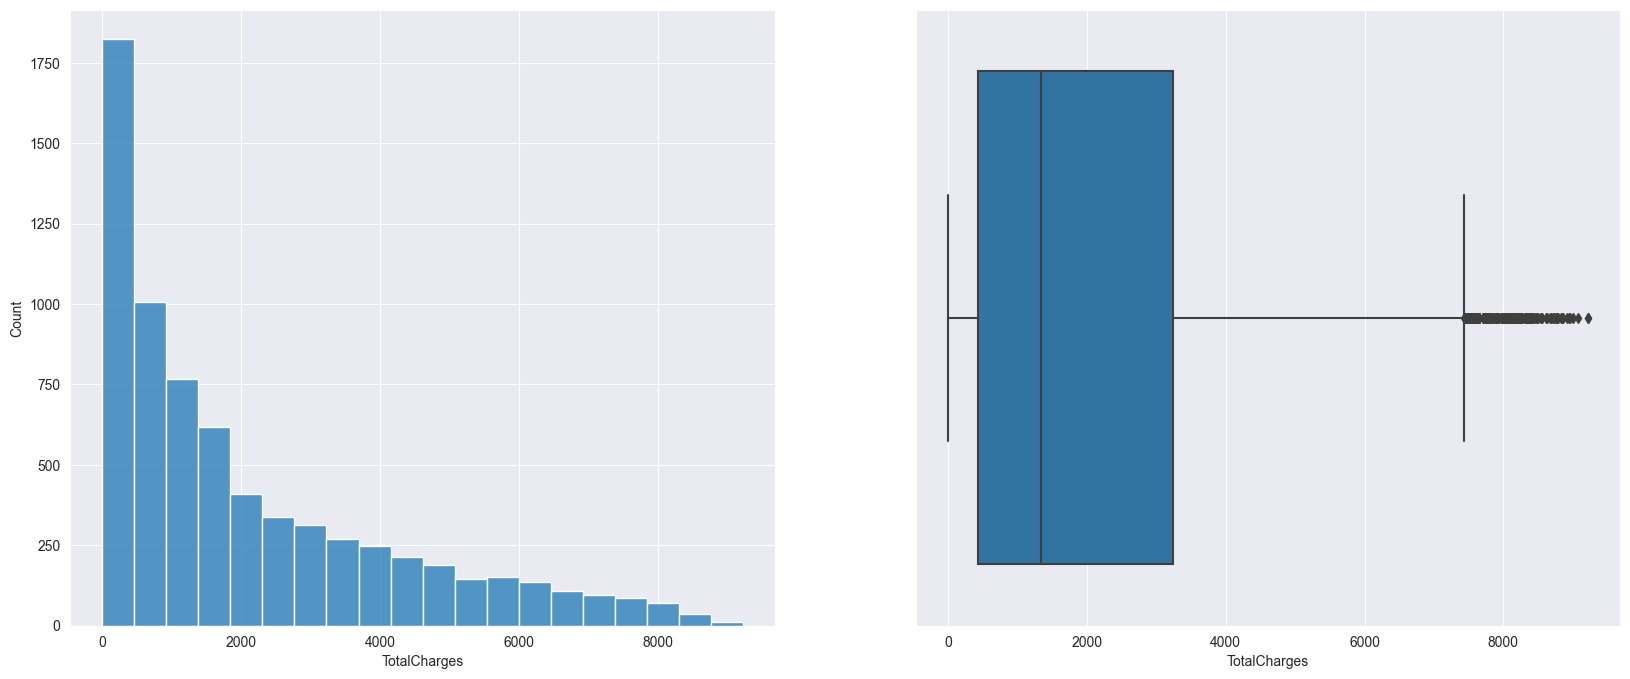

In [29]:
fig = plt.figure(figsize=(20, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
sns.histplot(contract['TotalCharges'], kde=False, bins=20, ax=ax1)
sns.boxplot(contract['TotalCharges'], ax=ax2)
plt.show()

In [30]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Type                7043 non-null   object 
 2   PaperlessBilling    7043 non-null   object 
 3   PaymentMethod       7043 non-null   object 
 4   MonthlyCharges      7043 non-null   float64
 5   TotalCharges        7043 non-null   float64
 6   tenure_days         7043 non-null   int64  
 7   is_active_contract  7043 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 392.2+ KB


### `personal`

In [31]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [32]:
personal.duplicated().sum()

0

In [33]:
personal.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No


In [34]:
personal['gender'].value_counts()

Male      3555
Female    3488
Name: gender, dtype: int64

In [35]:
personal['SeniorCitizen'].value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [36]:
personal['SeniorCitizen'] = personal['SeniorCitizen'].map(lambda x: True if x == 1 else False)

In [37]:
# personal = replace_with_bool(personal)

In [38]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   bool  
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: bool(1), object(4)
memory usage: 227.1+ KB


### `internet`

In [39]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [40]:
internet.duplicated().sum()

0

In [41]:
internet.head(2)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No


In [42]:
internet['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
Name: InternetService, dtype: int64

In [43]:
# internet = replace_with_bool(internet)

In [44]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


### `phone`

In [45]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [46]:
phone.duplicated().sum()

0

In [47]:
phone.head(2)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No


In [48]:
phone['MultipleLines'].value_counts()

No     3390
Yes    2971
Name: MultipleLines, dtype: int64

In [49]:
# phone = replace_with_bool(phone)

D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


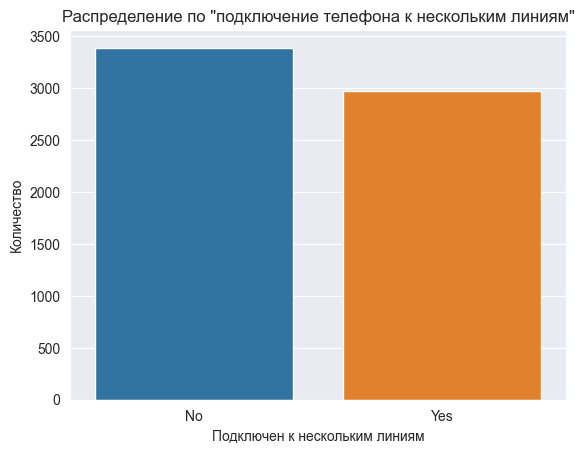

In [50]:
sns.countplot(phone['MultipleLines'])
plt.title('Распределение по "подключение телефона к нескольким линиям"')
plt.xlabel('Подключен к нескольким линиям')
plt.ylabel('Количество')
plt.show()

In [51]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


__Выводы__

- изменены типы данных признаков, содержащие два уникальных значения, на булевый
- добавлены новые признаки:
    - `tenure_days` — сколько дней клиент с компанией (если EndDate пустая — берем сегодняшнюю дату).
    - `begin_month` — месяц начала обслуживания (сезонный паттерн).
    - `begin_year` — год начала обслуживания (для трендов).
    - `is_active_contract` — бинарный признак, активен ли контракт сейчас __(таргет)__
- удалены признаки типа `timestamp`
- количество пользователей услуг связанных с интернетом меньше, чем всех пользователей при объединении появятся пропуски

## Объединение данных

In [52]:
data = (contract.merge(personal, how='left', on='customerID')
                .merge(internet, how='left', on='customerID')
                .merge(phone, how='left', on='customerID'))

In [53]:
data.head(5)

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_days,is_active_contract,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,31,True,Female,False,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,One year,No,Mailed check,56.95,2071.84,1036,True,Male,False,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,123,True,Male,False,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.30,1960.60,1371,True,Male,False,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.70,353.50,153,True,Female,False,No,No,Fiber optic,No,No,No,No,No,No,No


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Type                7043 non-null   object 
 2   PaperlessBilling    7043 non-null   object 
 3   PaymentMethod       7043 non-null   object 
 4   MonthlyCharges      7043 non-null   float64
 5   TotalCharges        7043 non-null   float64
 6   tenure_days         7043 non-null   int64  
 7   is_active_contract  7043 non-null   bool   
 8   gender              7043 non-null   object 
 9   SeniorCitizen       7043 non-null   bool   
 10  Partner             7043 non-null   object 
 11  Dependents          7043 non-null   object 
 12  InternetService     5517 non-null   object 
 13  OnlineSecurity      5517 non-null   object 
 14  OnlineBackup        5517 non-null   object 
 15  DeviceProtection    5517 non-null   object 
 16  TechSu

__Выводы__

Данные объединены в общий датафрейм.

Из информации видно, что количество записей с услугами интернета меньше, чем всего пользователей, скорее всего у оставшихся пользователей услуги не подключены

## Исследовательский анализ и предобработка данных объединенного датафрейма

In [55]:
def eda_describe_numeric(df, column, is_discrete=False, swap_axis=False):
    print(df[column].describe().T)
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    if is_discrete:
        if swap_axis:
            sns.countplot(y=column, data=df)
        else:
            sns.countplot(x=column, data=df)
    else:
        sns.histplot(df[column], kde=True, bins=int(np.ceil(np.log2(df.shape[0]))))
    plt.title(f'Распределение {column}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column])
    plt.title(f'Ящик с усами {column}')
    plt.show()

In [56]:
def eda_describe_categorical(df, column):
    print(df[column].describe(include='object').T)
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[column], order=df[column].value_counts().index)
    plt.title(f"Распределение {column}")
    plt.xticks(rotation=45)
    plt.show()

In [57]:
def eda_describe_feature(df, column, is_discrete=False, swap_axis=False):
    print('\n\tОписательная статистика столбца -', column)
    num_col_names = df.select_dtypes(include='number').columns.tolist()
    # для числовых переменных
    if column in num_col_names:
        eda_describe_numeric(df, column, is_discrete, swap_axis)

    # для категориальных переменных
    else:
        eda_describe_categorical(df, column)

In [58]:
data.duplicated().sum()

0

In [59]:
data.isna().sum()

customerID               0
Type                     0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
tenure_days              0
is_active_contract       0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
InternetService       1526
OnlineSecurity        1526
OnlineBackup          1526
DeviceProtection      1526
TechSupport           1526
StreamingTV           1526
StreamingMovies       1526
MultipleLines          682
dtype: int64

Пропуски в признаках заменяем на `False`, так как в датафрейме об интернет услугах о таких пользователях нет информации, значит эти услуги у них не подключены

In [60]:
columns_to_fillna = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV',
                     'StreamingMovies', 'MultipleLines']

data[columns_to_fillna] = data[columns_to_fillna].fillna('None')
data.isna().sum()

customerID            0
Type                  0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
tenure_days           0
is_active_contract    0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
MultipleLines         0
dtype: int64


	Описательная статистика столбца - Type
count               7043
unique                 3
top       Month-to-month
freq                3875
Name: Type, dtype: object


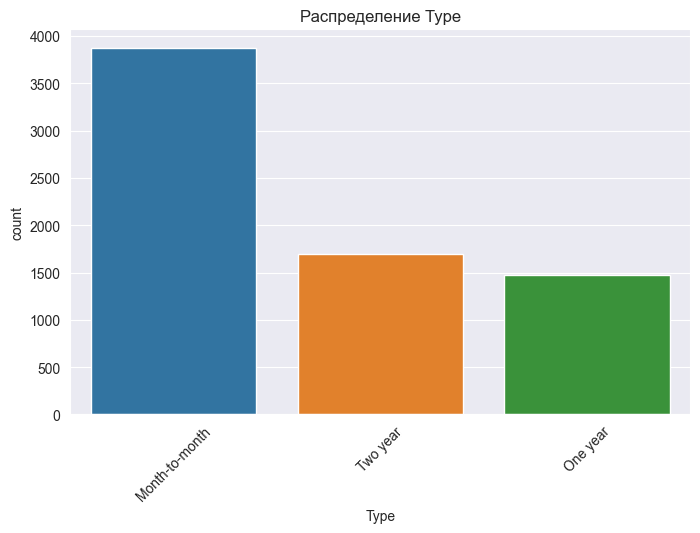

In [61]:
eda_describe_feature(data, 'Type')


	Описательная статистика столбца - PaperlessBilling
count     7043
unique       2
top        Yes
freq      4171
Name: PaperlessBilling, dtype: object


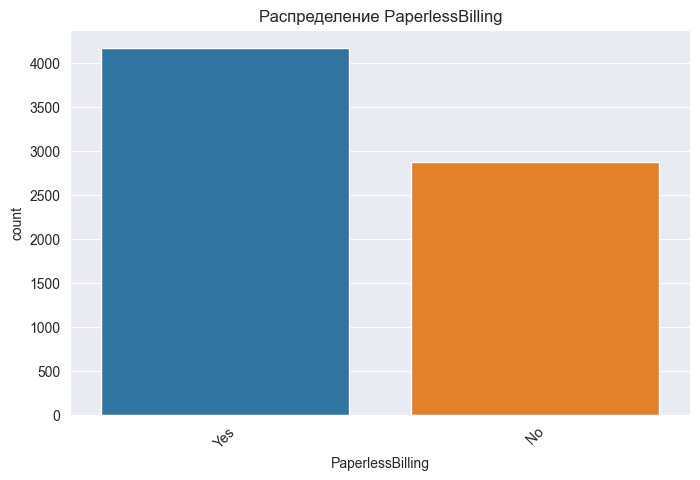

In [62]:
eda_describe_feature(data, 'PaperlessBilling')


	Описательная статистика столбца - PaymentMethod
count                 7043
unique                   4
top       Electronic check
freq                  2365
Name: PaymentMethod, dtype: object


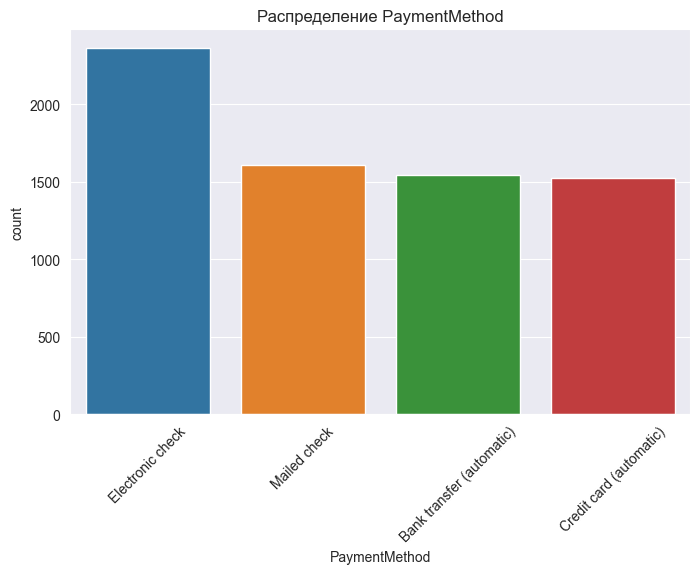

In [63]:
eda_describe_feature(data, 'PaymentMethod')


	Описательная статистика столбца - MonthlyCharges
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


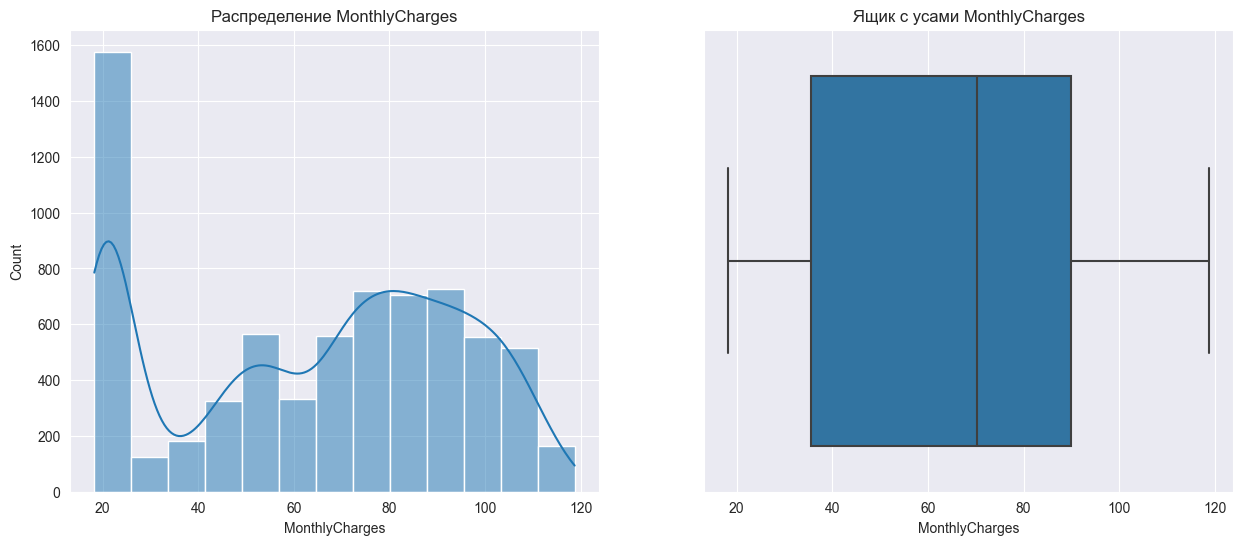

In [64]:
eda_describe_feature(data, 'MonthlyCharges')


	Описательная статистика столбца - TotalCharges
count    7043.000000
mean     2115.312885
std      2112.742814
min         0.000000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: TotalCharges, dtype: float64


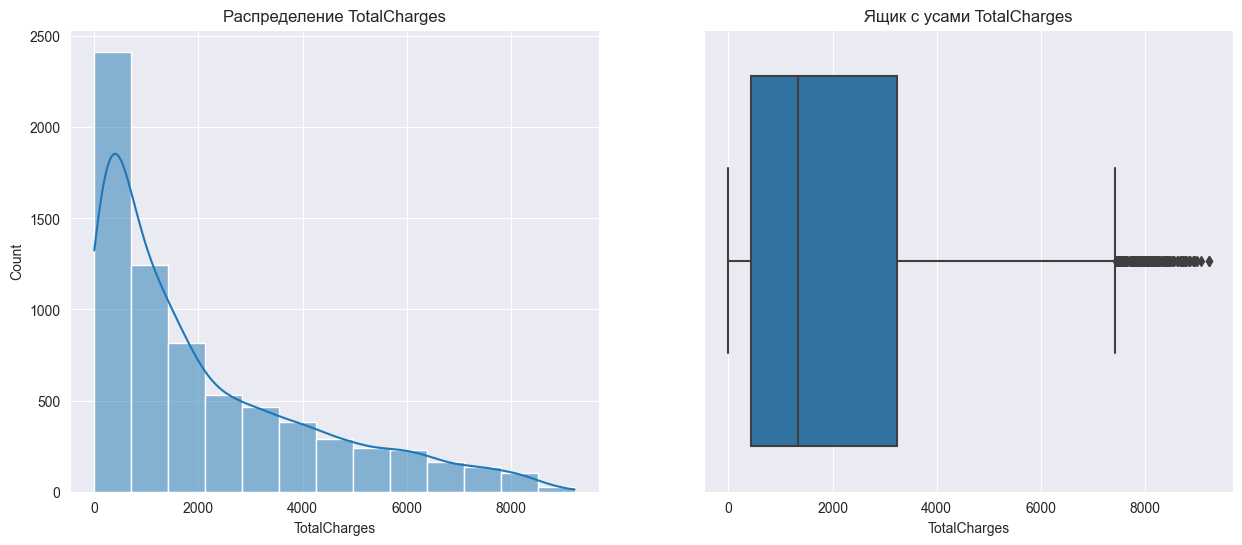

In [65]:
eda_describe_feature(data, 'TotalCharges')


	Описательная статистика столбца - tenure_days
count    7043.000000
mean      898.555729
std       683.130510
min         0.000000
25%       276.000000
50%       761.000000
75%      1461.000000
max      2314.000000
Name: tenure_days, dtype: float64


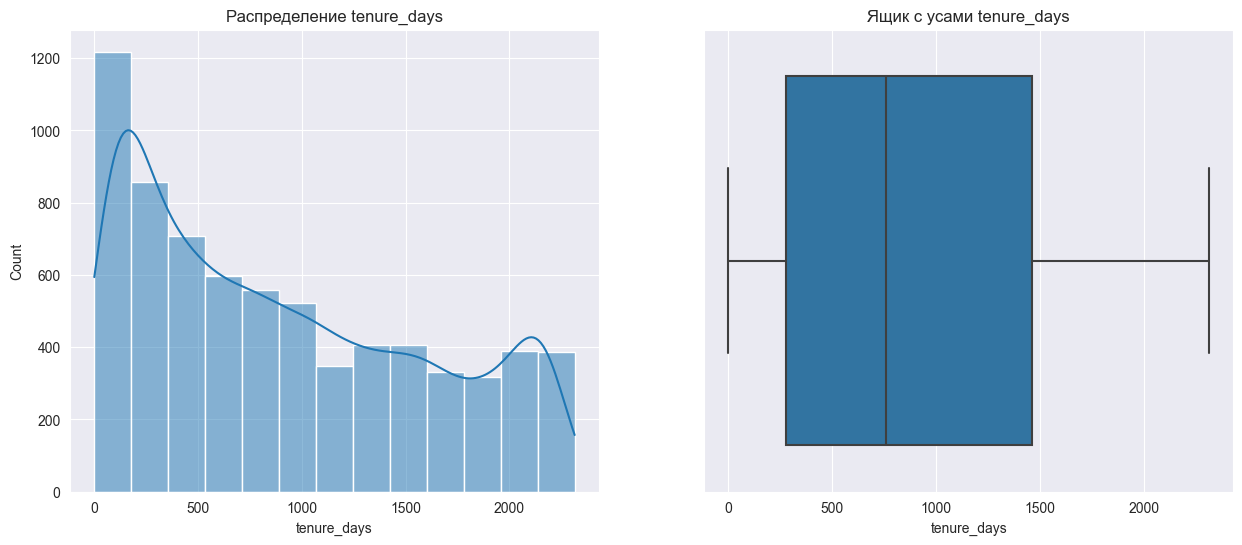

In [66]:
eda_describe_feature(data, 'tenure_days')


	Описательная статистика столбца - is_active_contract
count     7043
unique       2
top       True
freq      5942
Name: is_active_contract, dtype: object


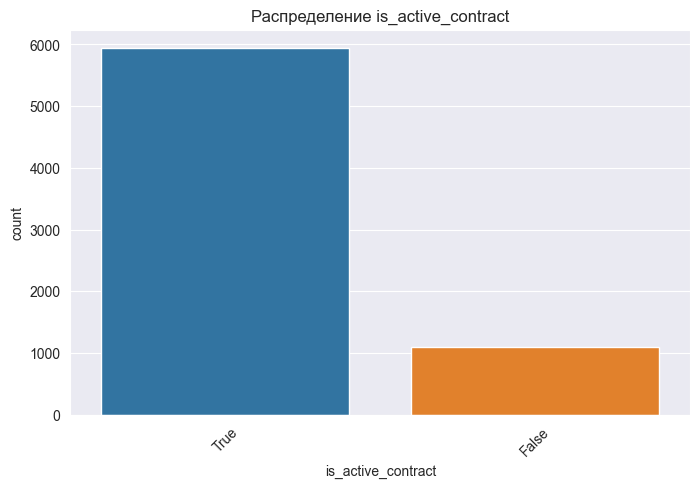

In [67]:
eda_describe_feature(data, 'is_active_contract')


	Описательная статистика столбца - SeniorCitizen
count      7043
unique        2
top       False
freq       5901
Name: SeniorCitizen, dtype: object


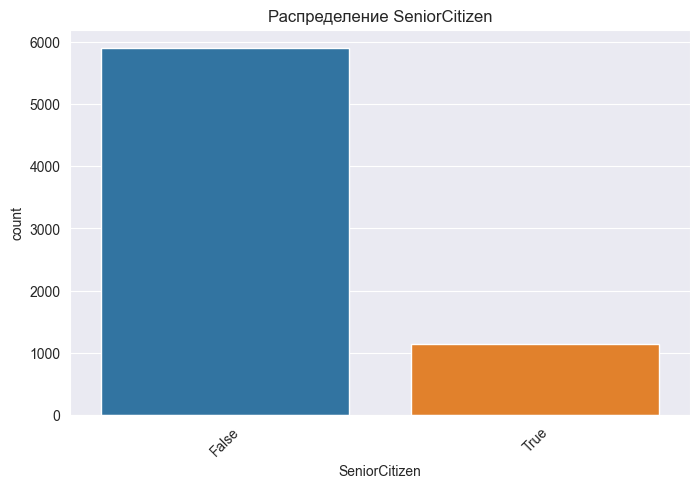

In [68]:
eda_describe_feature(data, 'SeniorCitizen')


	Описательная статистика столбца - Partner
count     7043
unique       2
top         No
freq      3641
Name: Partner, dtype: object


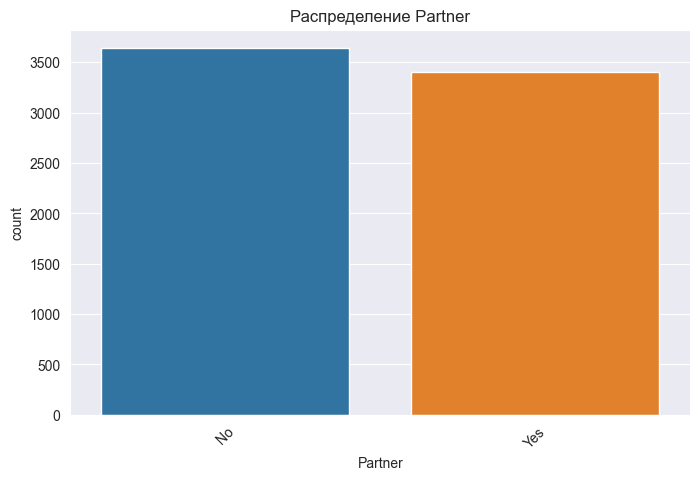

In [69]:
eda_describe_feature(data, 'Partner')


	Описательная статистика столбца - Dependents
count     7043
unique       2
top         No
freq      4933
Name: Dependents, dtype: object


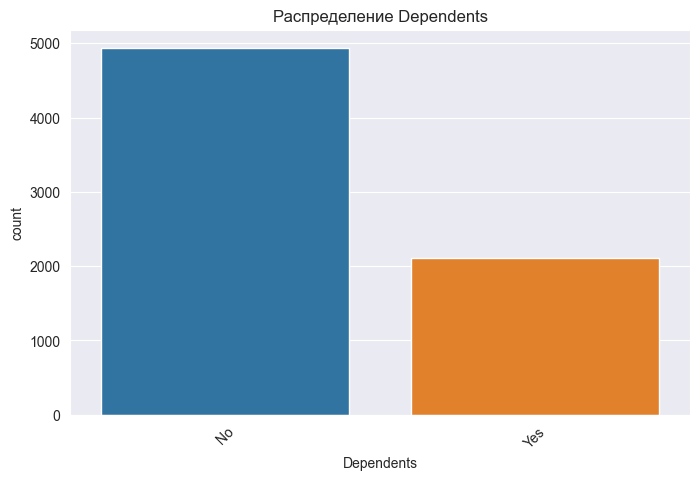

In [70]:
eda_describe_feature(data, 'Dependents')


	Описательная статистика столбца - gender
count     7043
unique       2
top       Male
freq      3555
Name: gender, dtype: object


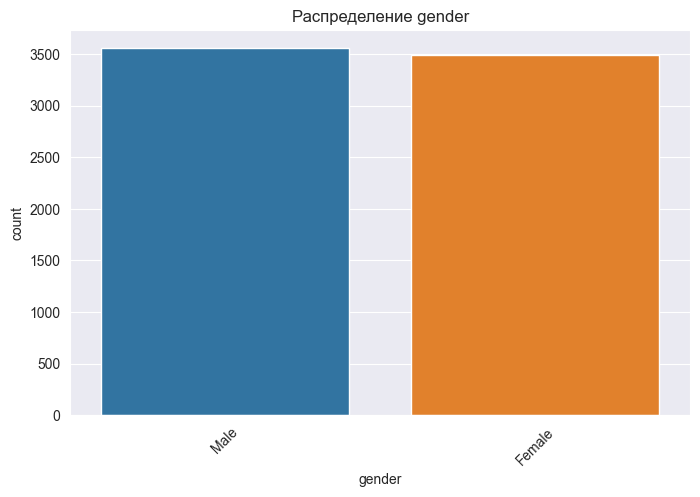

In [71]:
eda_describe_feature(data, 'gender')


	Описательная статистика столбца - InternetService
count            7043
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object


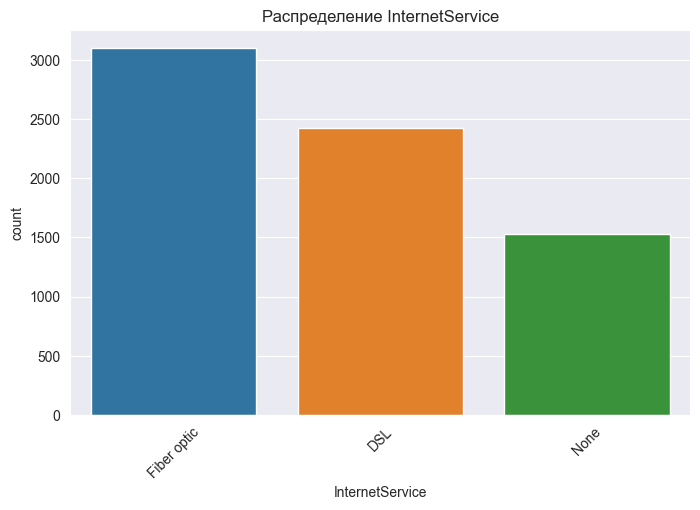

In [72]:
eda_describe_feature(data, 'InternetService')


	Описательная статистика столбца - OnlineSecurity
count     7043
unique       3
top         No
freq      3498
Name: OnlineSecurity, dtype: object


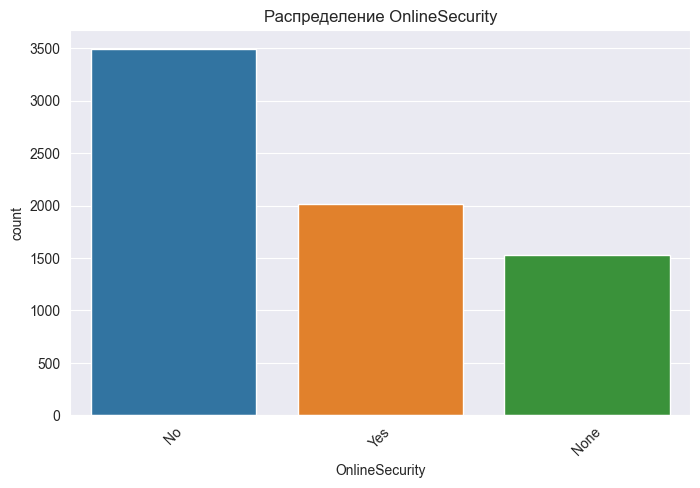

In [73]:
eda_describe_feature(data, 'OnlineSecurity')


	Описательная статистика столбца - OnlineBackup
count     7043
unique       3
top         No
freq      3088
Name: OnlineBackup, dtype: object


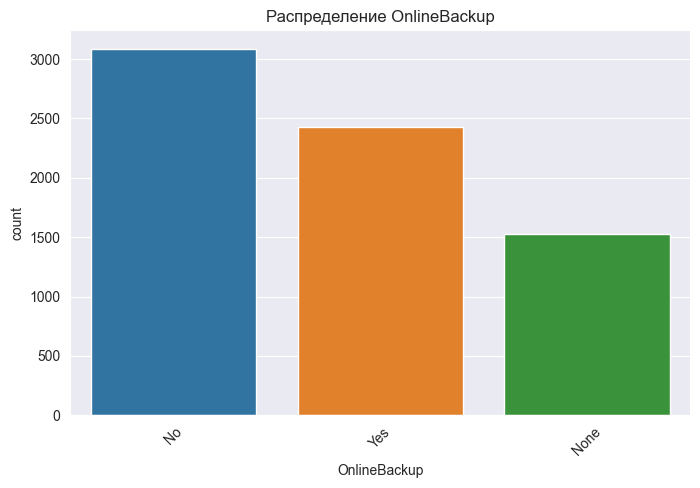

In [74]:
eda_describe_feature(data, 'OnlineBackup')


	Описательная статистика столбца - DeviceProtection
count     7043
unique       3
top         No
freq      3095
Name: DeviceProtection, dtype: object


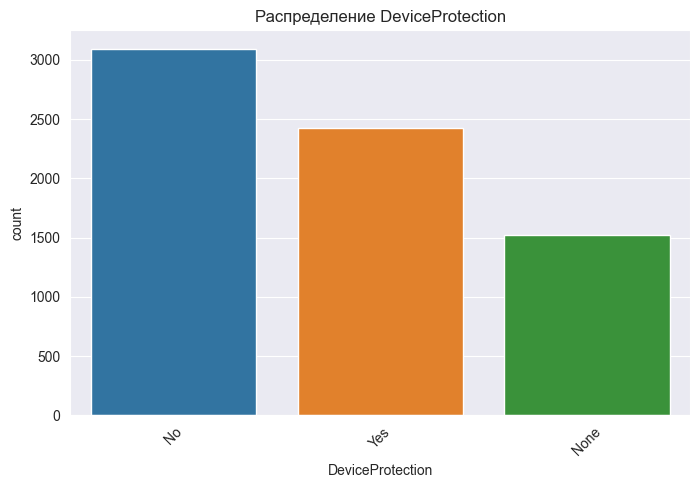

In [75]:
eda_describe_feature(data, 'DeviceProtection')


	Описательная статистика столбца - TechSupport
count     7043
unique       3
top         No
freq      3473
Name: TechSupport, dtype: object


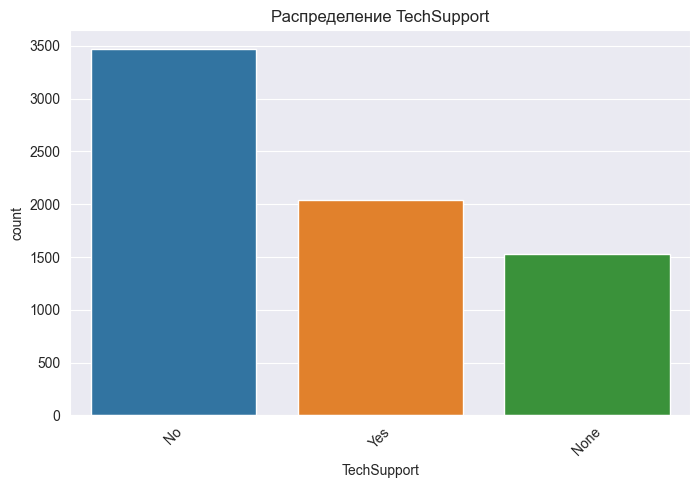

In [76]:
eda_describe_feature(data, 'TechSupport')


	Описательная статистика столбца - StreamingTV
count     7043
unique       3
top         No
freq      2810
Name: StreamingTV, dtype: object


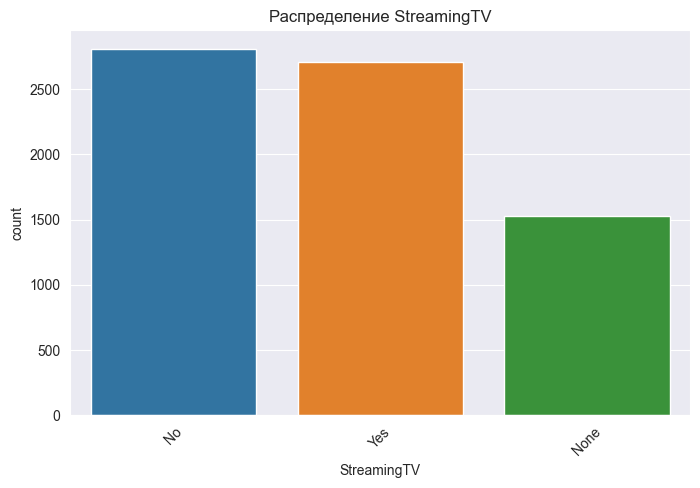

In [77]:
eda_describe_feature(data, 'StreamingTV')


	Описательная статистика столбца - StreamingMovies
count     7043
unique       3
top         No
freq      2785
Name: StreamingMovies, dtype: object


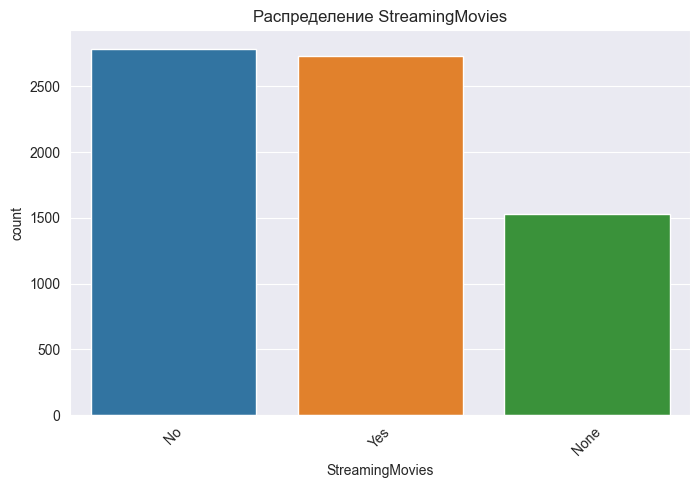

In [78]:
eda_describe_feature(data, 'StreamingMovies')


	Описательная статистика столбца - MultipleLines
count     7043
unique       3
top         No
freq      3390
Name: MultipleLines, dtype: object


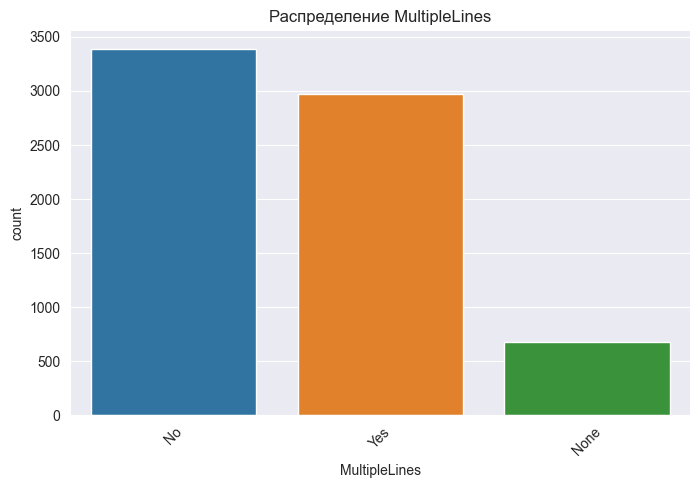

In [79]:
eda_describe_feature(data, 'MultipleLines')

__Вывод__

- `is_active_contract` - тагретный признак имеет сильный дисбаланс, его нужно будет учесть при обучении
- Среди категориальных признаков часть сбалансирована, часть содержит редкие категории. Потребуется обработка и кодирование.
- Количественные признаки без выбросов, но со смещёнными распределениями. Для деревьев не критично, для линейных моделей полезны преобразования.

### Корреляционный анализ

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Type                7043 non-null   object 
 2   PaperlessBilling    7043 non-null   object 
 3   PaymentMethod       7043 non-null   object 
 4   MonthlyCharges      7043 non-null   float64
 5   TotalCharges        7043 non-null   float64
 6   tenure_days         7043 non-null   int64  
 7   is_active_contract  7043 non-null   bool   
 8   gender              7043 non-null   object 
 9   SeniorCitizen       7043 non-null   bool   
 10  Partner             7043 non-null   object 
 11  Dependents          7043 non-null   object 
 12  InternetService     7043 non-null   object 
 13  OnlineSecurity      7043 non-null   object 
 14  OnlineBackup        7043 non-null   object 
 15  DeviceProtection    7043 non-null   object 
 16  TechSu

In [81]:
cat_col_names = data.drop(columns=['customerID']).select_dtypes(include='object').columns.tolist()
num_col_names = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [82]:
corr_matrix = data.drop(columns='customerID').phik_matrix(interval_cols=num_col_names)

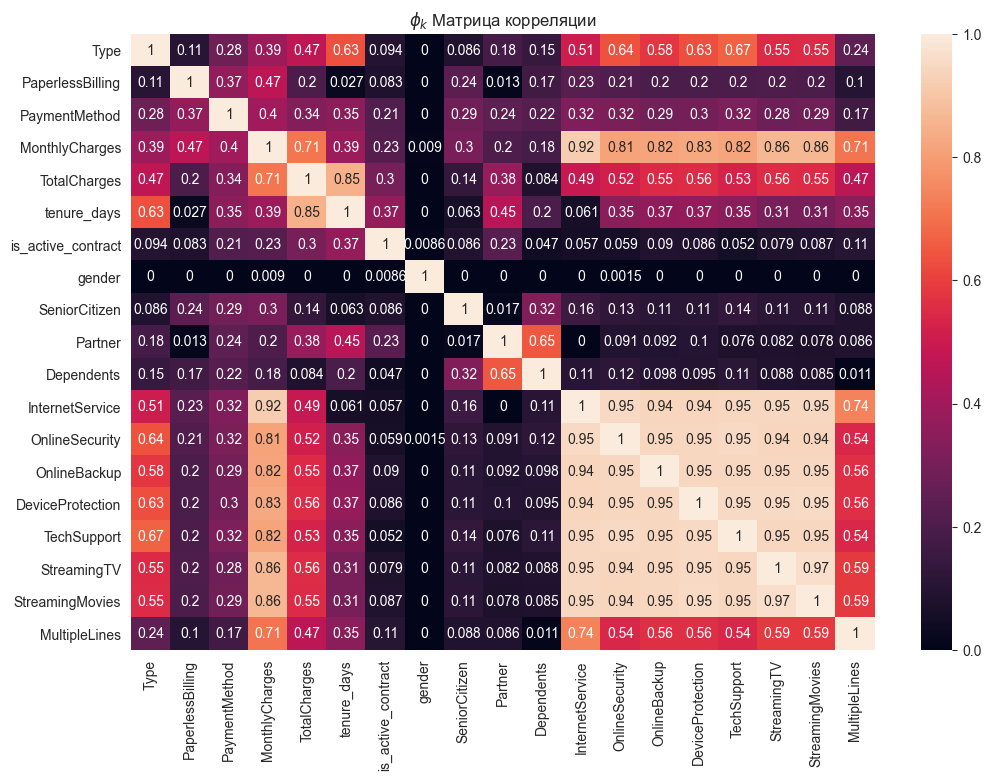

In [83]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title('$\phi_k$ Матрица корреляции')
plt.show()

In [84]:
def plot_scatter(df, feature_1, feature_2, target):
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df, x=feature_1, y=feature_2, hue=target, size=target, sizes=(20, 200))
    plt.title(f'Диаграмма рассеяния для признака MonthlyCharges и TotalCharges')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


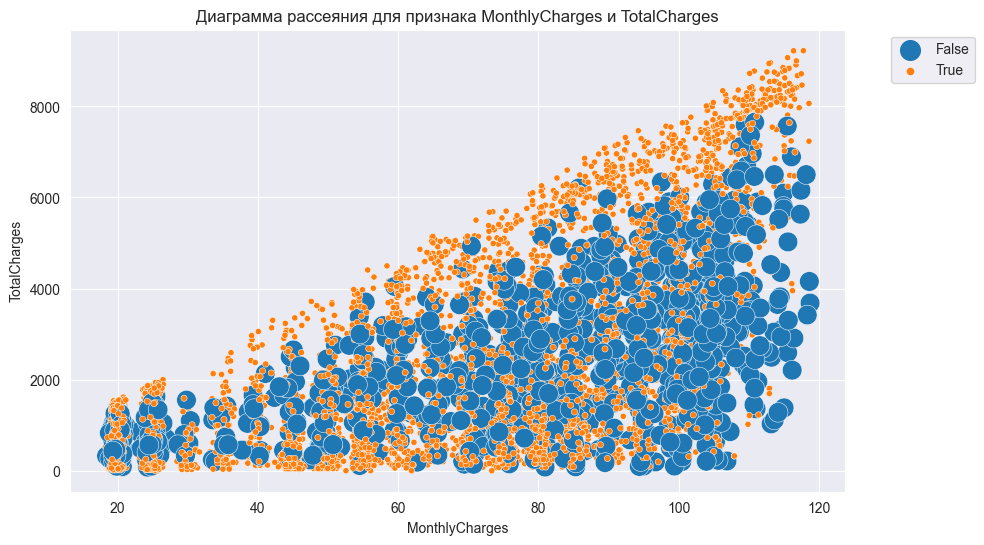

In [85]:
plot_scatter(data, 'MonthlyCharges', 'TotalCharges', 'is_active_contract')

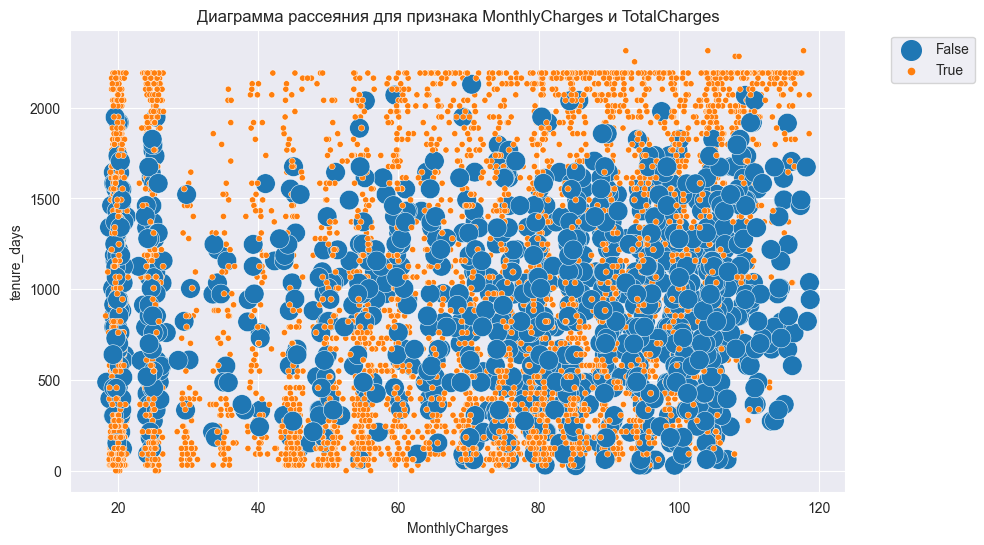

In [86]:
plot_scatter(data, 'MonthlyCharges', 'tenure_days', 'is_active_contract')

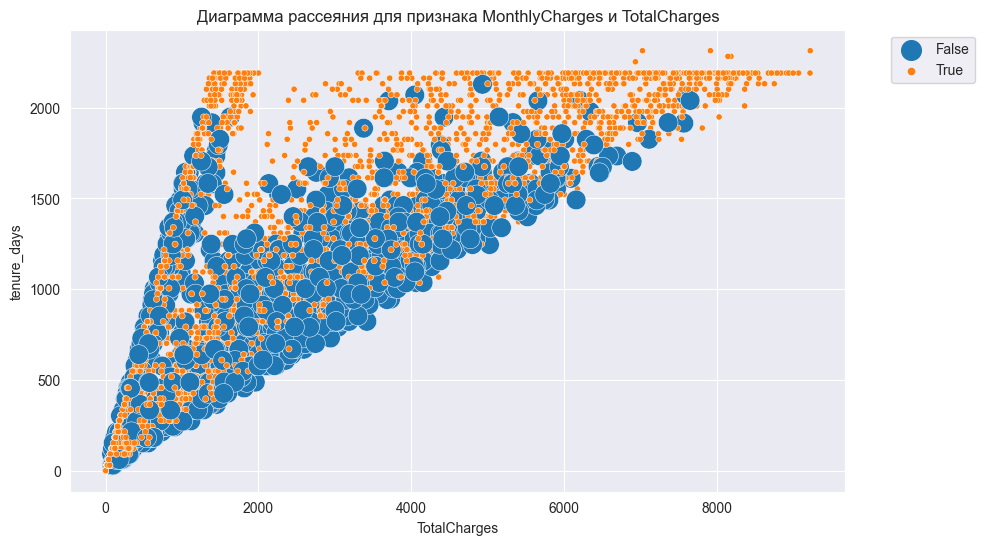

In [87]:
plot_scatter(data, 'TotalCharges', 'tenure_days', 'is_active_contract')

__Выводы__

- Очень сильные корреляции (может быть избыточность)
    - `MonthlyCharges` - `TotalCharges` (\~0.7) и `tenure_days` (\~0.53). А `TotalCharges` и `tenure_days` вообще коррелируют на 0.85. Это значит, что `TotalCharges` ~= `MonthlyCharges * tenure`.
    - `StreamingTV` - `StreamingMovies` (\~0.63). Возможно, это одна группа поведения ("стриминговые сервисы").

- Связанные производные признаки
    - `begin_year` - `tenure_days` (\~0.68) — ожидаемо, так как срок обслуживания связан с годом старта.

- Почти независимые признаки
    - `SeniorCitizen`, `Partner`, `Dependents` — слабая корреляция с остальными, но могут быть важны как демографические факторы.

- Большой отток клиентов идет либо в начале, либо от большого значения `MonthlyCharges`


## Подготовка данных

In [88]:
X = data.drop(columns=['is_active_contract', 'customerID'])
y = data['is_active_contract']


In [89]:
X.head(2)

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_days,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,Month-to-month,Yes,Electronic check,29.85,31.04,31,Female,False,Yes,No,DSL,No,Yes,No,No,No,No,None
1,One year,No,Mailed check,56.95,2071.84,1036,Male,False,No,No,DSL,Yes,No,Yes,No,No,No,No


In [90]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
bool_cols = X.select_dtypes(include='bool').columns.tolist()
num_cols = list((set(X.columns) - set(cat_cols + bool_cols)))

In [91]:
X.dtypes

Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
tenure_days           int64
gender               object
SeniorCitizen          bool
Partner              object
Dependents           object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MultipleLines        object
dtype: object

Препроцессинг

---

In [92]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scale", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("ohe", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), cat_cols),
        ("bool", "passthrough", bool_cols)
    ],
    remainder='drop'
)

Модели

---

In [93]:
logreg_pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(
        #class_weight='balanced',
        random_state=RANDOM_STATE)
    )
])

In [94]:
lgbm_pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', LGBMClassifier(
        #class_weight='balanced',
        random_state=RANDOM_STATE)
    )
])

In [95]:
tree_pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(
        random_state=RANDOM_STATE)
    )
])

Параметры

---

In [96]:
param_lgbm = {
    "clf__learning_rate": [0.3, 0.35, 0.4, 0.45, 0.5],
    "clf__num_leaves": range(20, 50, 2),
    "clf__max_depth": range(10, 30)
}

In [97]:
param_tree = {
    "clf__min_samples_split": range(2, 10),
    "clf__min_samples_leaf": range(2, 10),
    "clf__max_features": range(5, 15),
    "clf__max_depth": range(2, 5)
}

Кроссвалидация

---

In [98]:
lgbm_search = RandomizedSearchCV(lgbm_pipe,
                                 param_distributions=param_lgbm,
                                 n_iter=10,
                                 scoring='roc_auc',
                                 cv=3,
                                 n_jobs=-1,
                                 verbose=0,
                                 random_state=RANDOM_STATE)

In [99]:
tree_search = RandomizedSearchCV(tree_pipe,
                                 param_distributions=param_tree,
                                 n_iter=10,
                                 scoring='roc_auc',
                                 cv=3,
                                 n_jobs=-1,
                                 random_state=RANDOM_STATE)

## Обучение моделей машинного обучения

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

Обучение LightGBM

---

In [101]:
lgbm_search.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4456, number of negative: 826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.843620 -> initscore=1.685412
[LightGBM] [Info] Start training from score 1.685412


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'tenure_days']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Type',
                                                                                'PaperlessBilling',
                                                                                'PaymentMethod',
                                                                                'gend...
                                                                                'DeviceProtection',
                                                                                'TechSupport',
                                                                                'StreamingTV',
                                                                                'StreamingMovies',
                                                                                'MultipleLines']),
                                                                              ('bool',
                                                                               'passthrough',
                                                                               ['SeniorCitizen'])])),
                                             ('clf',
                                              LGBMClassifier(random_state=110825))]),
                   n_jobs=-1,
                   param_distributions={'clf__learning_rate': [0.3, 0.35, 0.4,
                                                               0.45, 0.5],
                                        'clf__max_depth': range(10, 30),
                                        'clf__num_leaves': range(20, 50, 2)},
                   random_state=110825, scoring='roc_auc')

In [102]:
comparison_table = {'model': [], 'best_score': [],'best_params': []}
fitted_lgbm = lgbm_search.best_estimator_

comparison_table['model'].append(lgbm_search.best_estimator_.named_steps['clf'].__class__.__name__)
comparison_table['best_score'].append(lgbm_search.best_score_)
comparison_table['best_params'].append(lgbm_search.best_params_)

Обучение DecisionTree

---

In [103]:
# Обучение DecisionTree
tree_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'tenure_days']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Type',
                                                                                'PaperlessBilling',
                                                                                'PaymentMethod',
                                                                                'gend...
                                                                                'StreamingTV',
                                                                                'StreamingMovies',
                                                                                'MultipleLines']),
                                                                              ('bool',
                                                                               'passthrough',
                                                                               ['SeniorCitizen'])])),
                                             ('clf',
                                              DecisionTreeClassifier(random_state=110825))]),
                   n_jobs=-1,
                   param_distributions={'clf__max_depth': range(2, 5),
                                        'clf__max_features': range(5, 15),
                                        'clf__min_samples_leaf': range(2, 10),
                                        'clf__min_samples_split': range(2, 10)},
                   random_state=110825, scoring='roc_auc')

In [104]:
fitted_tree = tree_search.best_estimator_

comparison_table['model'].append(tree_search.best_estimator_.named_steps['clf'].__class__.__name__)
comparison_table['best_score'].append(tree_search.best_score_)
comparison_table['best_params'].append(tree_search.best_params_)

Создание ансамбля

---

In [105]:
ensemble = VotingClassifier(
    estimators=[
        ("logreg", logreg_pipe),
        ("lgbm", fitted_lgbm),
        ("tree", fitted_tree)
    ],
    voting="soft"  # усредняем вероятности
)

In [106]:
ensemble.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4456, number of negative: 826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.843620 -> initscore=1.685412
[LightGBM] [Info] Start training from score 1.685412


VotingClassifier(estimators=[('logreg',
                              Pipeline(steps=[('preprocess',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('scale',
                                                                                                 StandardScaler())]),
                                                                                ['MonthlyCharges',
                                                                                 'TotalCharges',
                                                                                 'tenure_days']),
                                                                               ('cat',
                                                                                Pipeline(steps=[('ohe',
                                                                                                 OneHotEncoder(drop='first',
                                                                                                               handle_unknown='ignore',
                                                                                                               sparse_output=False))]),
                                                                                ['Type',
                                                                                 'PaperlessBilling',
                                                                                 'PaymentMethod',...
                                                                                 'PaymentMethod',
                                                                                 'gender',
                                                                                 'Partner',
                                                                                 'Dependents',
                                                                                 'InternetService',
                                                                                 'OnlineSecurity',
                                                                                 'OnlineBackup',
                                                                                 'DeviceProtection',
                                                                                 'TechSupport',
                                                                                 'StreamingTV',
                                                                                 'StreamingMovies',
                                                                                 'MultipleLines']),
                                                                               ('bool',
                                                                                'passthrough',
                                                                                ['SeniorCitizen'])])),
                                              ('clf',
                                               DecisionTreeClassifier(max_depth=4,
                                                                      max_features=13,
                                                                      min_samples_leaf=9,
                                                                      min_samples_split=8,
                                                                      random_state=110825))]))],
                 voting='soft')

Логрег для интерпретации коэффициентов

---

In [107]:
fitted_logreg = ensemble.named_estimators_['logreg']
logreg_clf = fitted_logreg.named_steps['clf']
coefs = logreg_clf.coef_.ravel()
intercept = logreg_clf.intercept_[0]

In [108]:
# Берём шаг препроцессинга из того же пайплайна
prep = fitted_logreg.named_steps["preprocess"]
feature_names = prep.get_feature_names_out()

coef_table = sorted(
    zip(feature_names, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)
# coef_table: список (имя_признака, коэффициент), отсортировано по |coef|
coef_table = pd.DataFrame(coef_table, columns=['feature', 'coefficient'])
coef_table.head(10)

,feature,coefficient
0,cat__Type_Two year,-1.694668
1,cat__Type_One year,-1.412137
2,num__TotalCharges,1.201664
3,cat__PaymentMethod_Mailed check,0.876113
4,cat__MultipleLines_Yes,-0.868730
5,cat__OnlineBackup_Yes,-0.858625
6,cat__InternetService_Fiber optic,-0.715702
7,cat__Partner_Yes,-0.701193
8,cat__StreamingMovies_Yes,-0.498362
9,cat__PaymentMethod_Electronic check,0.429758


## Выбор лучшей модели

In [109]:
def calc_metrics(model, X_valid=X_test, y_valid=y_test):
    y_proba = model.predict_proba(X_valid)[:, 1]
    y_pred = model.predict(X_valid)

    roc_auc = roc_auc_score(y_valid, y_proba)

    print(f'ROC-AUC: {roc_auc}')
    print(f'Accuracy: {accuracy_score(y_valid, y_pred)}')

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--', label='Случайный выбор')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC-Кривая')
    plt.legend(loc='lower right')
    plt.show()

    cm = confusion_matrix(y_valid, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.ylabel('True label')
    plt.xlabel('Predicted')


Сравнение моделей

---

In [110]:
comp_table = pd.DataFrame(comparison_table).sort_values(by='best_score', ascending=False)
comp_table.head()

,model,best_score,best_params
0,LGBMClassifier,0.856346,"{'clf__num_leaves': 26, 'clf__max_depth': 29, ..."
1,DecisionTreeClassifier,0.764852,"{'clf__min_samples_split': 8, 'clf__min_sample..."


Проверка лучшей модели

---

ROC-AUC: 0.8913752600024472
Accuracy: 0.8989210675752414


D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


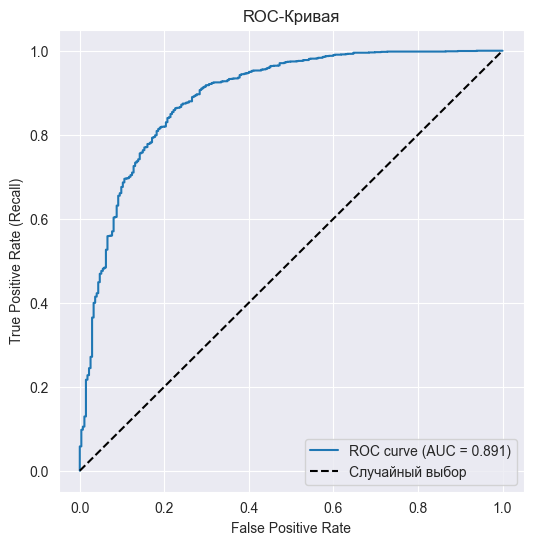

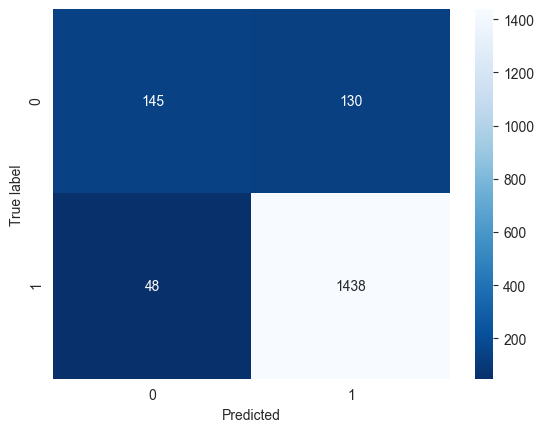

In [111]:
calc_metrics(lgbm_search)

In [112]:
importances_gain = lgbm_search.best_estimator_.named_steps['clf'].booster_.feature_importance(importance_type="gain")
feature_names = lgbm_search.best_estimator_.named_steps['preprocess'].get_feature_names_out().tolist()

pd.DataFrame({
    "feature": feature_names,
    "gain_importance": importances_gain
}).sort_values(by="gain_importance", ascending=False)

,feature,gain_importance
2,num__tenure_days,2888.605942
0,num__MonthlyCharges,1027.229202
1,num__TotalCharges,979.632358
4,cat__Type_Two year,292.806961
17,cat__OnlineBackup_Yes,156.643378
10,cat__Partner_Yes,156.486393
8,cat__PaymentMethod_Mailed check,117.135251
3,cat__Type_One year,113.408115
27,cat__MultipleLines_Yes,112.985391
5,cat__PaperlessBilling_Yes,105.649720


Проверка на ансамбле

---

ROC-AUC: 0.8841796158081487
Accuracy: 0.8779102782509938


D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


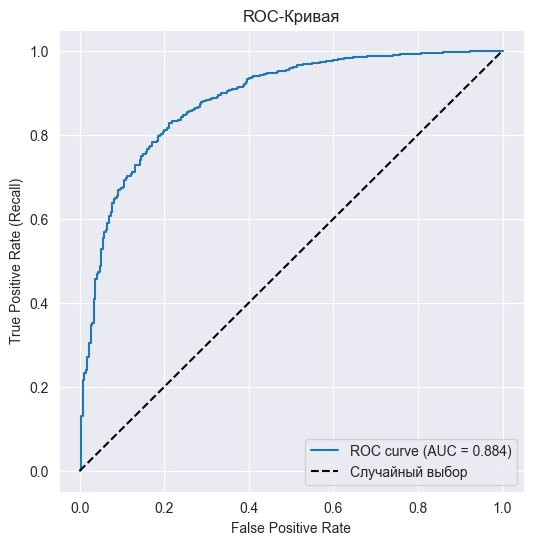

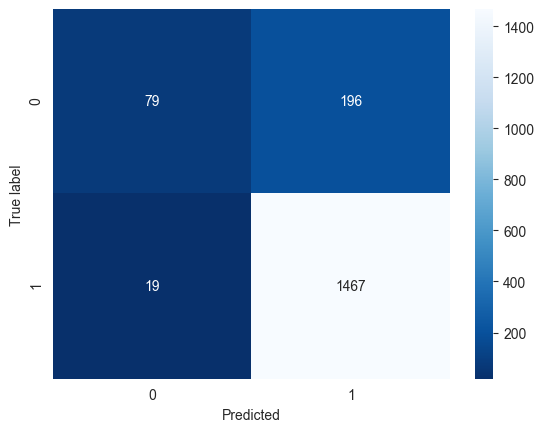

In [113]:
calc_metrics(ensemble)

## Общий вывод и рекомендации заказчику

__Выводы__

---
- Размер выборки ~7 000 клиентов

- Есть выбросы в `TotalCharges` для новых пользователей нет значений. Пропуски заменены на 0

- Целевая переменная `is_active_contract` имеет сильный дисбаланс

- Большой отток клиентов идет либо в начале, либо от большого значения `MonthlyCharges`

- Составлена сравнительная таблица, отсортированная от лучшей до худшей модели, согласно метрики ROC-AUC

- __Лучшая модель - LightGBMClassifier__ со следующими параметрами:
    - `num_leaves`: 22
    - `max_depth`: 16
    - `learning_rate`: 0.45

- Значение метрики __ROC-AUC__ на лучшей модели на тестовой выборке равно __0.88__, что больше заявленных __0.89__

- Ансамбль показал немного хуже результаты (ROC-AUC ~= 0.88)

__Рекомендации__

---
Исходя из важности признаков:

1. `tenure_days` (с большим отрывом лидер)

Чем дольше клиент остаётся, тем меньше риск оттока. Первые месяцы — самые критичные для удержания.

2. `MonthlyCharges` и `TotalCharges`

Высокая ежемесячная плата повышает риск оттока (особенно если это новые клиенты). Дорогие тарифы требуют дополнительных преимуществ (скидки, бонусы, гибкость тарифа).

3. `Type_Two year` и `Type_One year` (длительность контракта)

Годовые и двухгодовые контракты резко снижают отток. Стимулировать переход с помесячного тарифа на годовой (например, бонус + бесплатный месяц).

4. `Partner` (есть ли супруг/супруга)

Клиенты с партнёром стабильнее. Одиноким клиентам стоит предложить дополнительные «привязки» (например, скидку на семейный тариф).

5. `OnlineBackup` и `MultipleLines`

Дополнительные услуги снижают отток: чем больше сервисов подключено, тем меньше вероятность ухода. Продвигать покупку сразу нескольких услуг.

6. `PaymentMethod_Mailed check`

Почтовый чек — "устаревший" метод, такие клиенты чаще уходят. Мотивировать переход на автоплатежи или онлайн-оплату.

7. `gender_Male` (относительно слабый фактор)

Разница между мужчинами и женщинами есть, но она гораздо слабее, чем у других признаков.